In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as spy

In [31]:
def input_drive(t, T, A):
    if t < 0:
        return 0 + 0j
    if t < T:
        return A
    return 0 + 0j

def fun(t,y, delta, kappa, T , A):
    return -1*(1j*delta + 0.5*kappa)*y - np.sqrt(kappa)*input_drive(t, T, A)

In [44]:
delta = 2
kappa = 4
T = 20 / kappa
A = 4 * np.exp(-1j * np.pi / 2)
times = np.linspace(0, 30 / kappa, 1000)

result = spy.integrate.solve_ivp(fun, [times[0], times[-1]], [0 + 0j], t_eval=times, args=(delta, kappa, T, A)) # make sure initial condition is complex
alpha = result.y[0]
beta_out = np.sqrt(kappa) * alpha + np.array([input_drive(t, T, A) for t in times], dtype=complex)

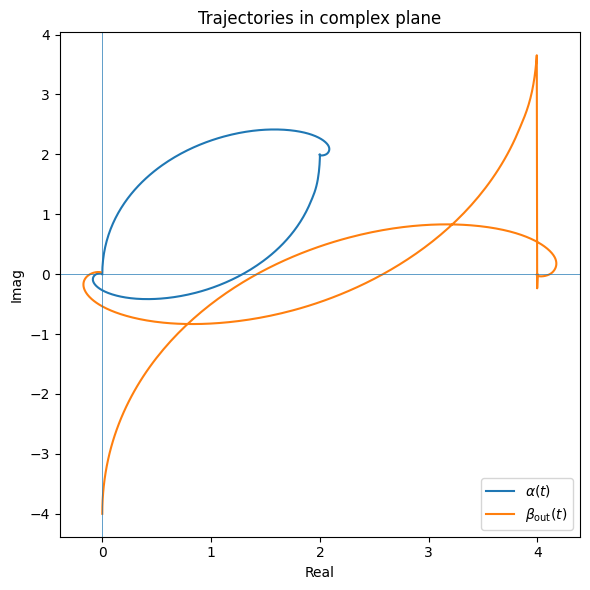

In [45]:
plt.figure(figsize=(6, 6))
plt.plot(alpha.real, alpha.imag, label=r'$\alpha(t)$')
plt.plot(beta_out.real, beta_out.imag, label=r'$\beta_{\rm out}(t)$')
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title("Trajectories in complex plane")
plt.legend()
plt.tight_layout()
plt.show()

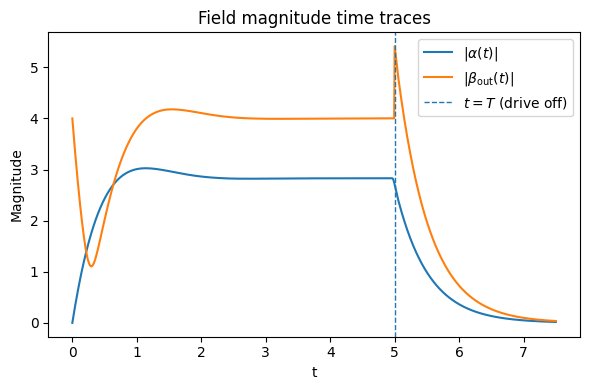

In [46]:
plt.figure(figsize=(6, 4))
plt.plot(times, np.abs(alpha), label=r'$|\alpha(t)|$')
plt.plot(times, np.abs(beta_out), label=r'$|\beta_{\rm out}(t)|$')
plt.axvline(T, linestyle='--', linewidth=1.0, label=r'$t=T$ (drive off)')
plt.xlabel("t")
plt.ylabel("Magnitude")
plt.title("Field magnitude time traces")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
print(np.abs(alpha)[500])
print(np.abs(-np.sqrt(kappa) * A / (1j * delta + 0.5 * kappa)))

2.827664816099947
2.82842712474619
